In [47]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
import statsmodels.api as sm
from statsmodels.formula.api import ols
# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, anderson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
# VIF값을 계산하기 위한 참조
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [48]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [49]:
origin = load_data('sk-diabetes')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab12_/sk-diabetes.xlsx
[desc] 442명의 당뇨병 환자를 대상으로 한 검사 결과 데이터. 독립변수 표준화 적용됨 (출처: sklearn 내장 데이터)

field    description
-------  -----------------------
age      나이
sex      성별
bmi      bmi지수(비만도)
bp       평균혈압
s1 ~ s6  6종류의 혈액검사 수치
target   당뇨병 진행률(종속변수)


===== 데이터 크기 확인 =====
데이터셋 크기: (442, 11)
열 개수: 11
행 개수: 442

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135


📘 #02. 종속변수 무게에 영향을 주는 요인 확인

📝 1차 분석

In [50]:
df1 = origin.copy()
yname = 'target'
x = df1.drop(yname, axis=1)
y = df1[yname]
x_input = sm.add_constant(x)
fit = sm.OLS(y, x_input).fit()
tbl1 = fit.summary()

In [51]:
def ols_report(tbl, data):
    """
    OLS summary(tbl)와 데이터프레임(data)을 받아 회귀계수 표(rdf),
    모델 적합도 요약(result_report), 모형 보고 문장(model_report),
    변수별 보고 리스트(variable_reports)를 반환한다.
    """

    # 독립변수 이름(상수항 제외)
    xnames = [n for n in fit.model.exog_names if n != "const"]

    # 독립변수 부분 데이터 (VIF 계산용)
    indi_df = data.filter(xnames)

    # 독립변수 결과 저장 리스트
    variables = []

    # 회귀계수 테이블(tbl.tables[1])에서 정보 추출
    for i, v in enumerate(tbl.tables[1].data):
        name = v[0].strip()

        # 유효한 독립변수만 처리
        if name not in xnames:
            continue

        # VIF 계산
        j = list(indi_df.columns).index(name)
        vif = variance_inflation_factor(indi_df, j)

        # p-value
        p = float(v[4].strip())

        # 유의성 별표 함수
        def stars(p):
            return (
                "//*" if p < 0.001 else
                "/*" if p < 0.01 else
                "*" if p < 0.05 else
                ""
            )

        # 변수 정보 누적
        variables.append({
            "종속변수": yname,
            "독립변수": name,
            "B": v[1].strip(),
            "표준오차": v[2].strip(),
            "Beta": float(fit.params[name]) * (
                data[name].std(ddof=1) / data[yname].std(ddof=1)
            ),
            "t": f"{v[3].strip()}{stars(p)}",
            "p-value": p,
            "공차": 1 / vif,
            "vif": vif
        })

    rdf = DataFrame(variables)

    # --------------------------------------------------
    # summary 표에서 적합도 정보 추출
    # --------------------------------------------------
    result_dict = {}

    for tbl_idx in [0, 2]:
        for item in tbl.tables[tbl_idx].data:
            n = len(item)
            for i in range(0, n, 2):
                key = item[i].strip()[:-1]
                value = item[i + 1].strip()
                if key and value:
                    result_dict[key] = value

    # 적합도 보고 문자열
    result_report = (
        f"R({result_dict['R-squared']}), "
        f"R^2({result_dict['Adj. R-squared']}), "
        f"F({result_dict['F-statistic']}), "
        f"유의확률({result_dict['Prob (F-statistic)']}), "
        f"Durbin-Watson({result_dict['Durbin-Watson']})"
    )

    # --------------------------------------------------
    # 모형 보고 문장
    # --------------------------------------------------
    f_p = float(result_dict['Prob (F-statistic)'])
    sig_model = "유의하다" if f_p < 0.05 else "유의하지 않다"
    comp_sign = "<" if f_p < 0.05 else ">"

    tpl = (
        "%s에 대하여 %s로 예측하는 회귀분석을 실시한 결과, "
        "이 회귀모형은 통계적으로 %s(F(%s, %s) = %s, p %s 0.05)."
    )

    model_report = tpl % (
        rdf['종속변수'][0],
        ",".join(list(rdf['독립변수'])),
        sig_model,
        result_dict['Df Model'],
        result_dict['Df Residuals'],
        result_dict['F-statistic'],
        comp_sign
    )

    # --------------------------------------------------
    # 변수별 보고 문장 리스트
    # --------------------------------------------------
    variable_reports = []
    sentence = "%s의 회귀계수는 %s(p %s 0.05)로, %s에 대하여 %s 예측변인인 것으로 나타났다."

    for i in rdf.index:
        row = rdf.iloc[i]
        pv = float(row['p-value'])
        comp = "<" if pv < 0.05 else ">"
        desc = "유의미한" if pv < 0.05 else "유의하지 않은"

        variable_reports.append(
            sentence % (
                row['독립변수'],
                row['B'],
                comp,
                row['종속변수'],
                desc
            )
        )

    return rdf, result_report, model_report, variable_reports




In [52]:
rdf, r, m, v = ols_report(tbl1, df1)
display(rdf)
print(m)

,종속변수,독립변수,B,표준오차,Beta,t,p-value,공차,vif
0,target,age,-10.0099,59.749,-0.006183,-0.168,0.867,0.821486,1.217307
1,target,sex,-239.8156,61.222,-0.148130,-3.917//*,0.000,0.782429,1.278071
2,target,bmi,519.8459,66.533,0.321100,7.813//*,0.000,0.662499,1.509437
3,target,bp,324.3846,65.422,0.200367,4.958//*,0.000,0.685200,1.459428
4,target,s1,-792.1756,416.680,-0.489314,-1.901,0.058,0.016891,59.202510
5,target,s2,476.7390,339.030,0.294474,1.406,0.160,0.025515,39.193370
6,target,s3,101.0433,212.531,0.062413,0.475,0.635,0.064926,15.402156
7,target,s4,177.0632,161.476,0.109369,1.097,0.273,0.112473,8.890986
8,target,s5,751.2737,171.900,0.464049,4.370//*,0.000,0.099246,10.075967
9,target,s6,67.6267,65.984,0.041772,1.025,0.306,0.673572,1.484623


target에 대하여 age,sex,bmi,bp,s1,s2,s3,s4,s5,s6로 예측하는 회귀분석을 실시한 결과, 이 회귀모형은 통계적으로 유의하다(F(10, 431) = 46.27, p < 0.05).


📝 2차 분석<br>
VIF값이 가장 높은 s1을 제거하고 다시 분석한다.

In [53]:
df2 = df1.drop('s1', axis=1)
yname = 'target'
x = df2.drop(yname, axis=1)
y = df2[yname]
x_input = sm.add_constant(x)
fit = sm.OLS(y, x_input).fit()
tbl2 = fit.summary()
rdf, r, m, v = ols_report(tbl2, df2)
display(rdf)
print(m)

,종속변수,독립변수,B,표준오차,Beta,t,p-value,공차,vif
0,target,age,-7.9150,59.920,-0.004889,-0.132,0.895,0.821765,1.216892
1,target,sex,-234.1555,61.335,-0.144634,-3.818//*,0.000,0.784284,1.275049
2,target,bmi,528.5315,66.577,0.326465,7.939//*,0.000,0.665637,1.502320
3,target,bp,319.7634,65.574,0.197512,4.876//*,0.000,0.686147,1.457413
4,target,s2,-143.2818,92.922,-0.088503,-1.542,0.124,0.341701,2.926535
5,target,s3,-250.5971,105.002,-0.154790,-2.387*,0.017,0.267602,3.736890
6,target,s4,70.4496,151.883,0.043516,0.464,0.643,0.127899,7.818670
7,target,s5,461.8393,80.068,0.285270,5.768//*,0.000,0.460222,2.172865
8,target,s6,69.1270,66.179,0.042699,1.045,0.297,0.673668,1.484410


target에 대하여 age,sex,bmi,bp,s2,s3,s4,s5,s6로 예측하는 회귀분석을 실시한 결과, 이 회귀모형은 통계적으로 유의하다(F(9, 432) = 50.71, p < 0.05).


📝 3차 분석<br>
p-value가 0.05보다 큰 항목을 제거하고 다시 분석

In [54]:
xnames = list(rdf[rdf['p-value'] > 0.05]['독립변수'])
xnames

['age', 's2', 's4', 's6']

In [55]:
df3 = df2.drop(xnames, axis=1)
df3.head()

,sex,bmi,bp,s3,s5,target
0,0.050680,0.061696,0.021872,-0.043401,0.019907,151
1,-0.044642,-0.051474,-0.026328,0.074412,-0.068332,75
2,0.050680,0.044451,-0.005670,-0.032356,0.002861,141
3,-0.044642,-0.011595,-0.036656,-0.036038,0.022688,206
4,-0.044642,-0.036385,0.021872,0.008142,-0.031988,135


📘 #03. 잔차 검정

📝 1. 선형성 검정

RESET 테스트 통계량 확인

In [56]:
reset_res = linear_reset(fit, power=2, use_f=True)
print(f"RESET F-statistic: {reset_res.fvalue:.4f}")
print(f"p-value: {reset_res.pvalue:.4f}")
if reset_res.pvalue < 0.05:
    print("선형성/기능형 위배 가능성이 있음 (5% 유의수준)")
else:
    print("선형성 가정 위배 근거 없음 (5% 유의수준)")

RESET F-statistic: 1.3048
p-value: 0.2540
선형성 가정 위배 근거 없음 (5% 유의수준)


Q-Q Plot 확인

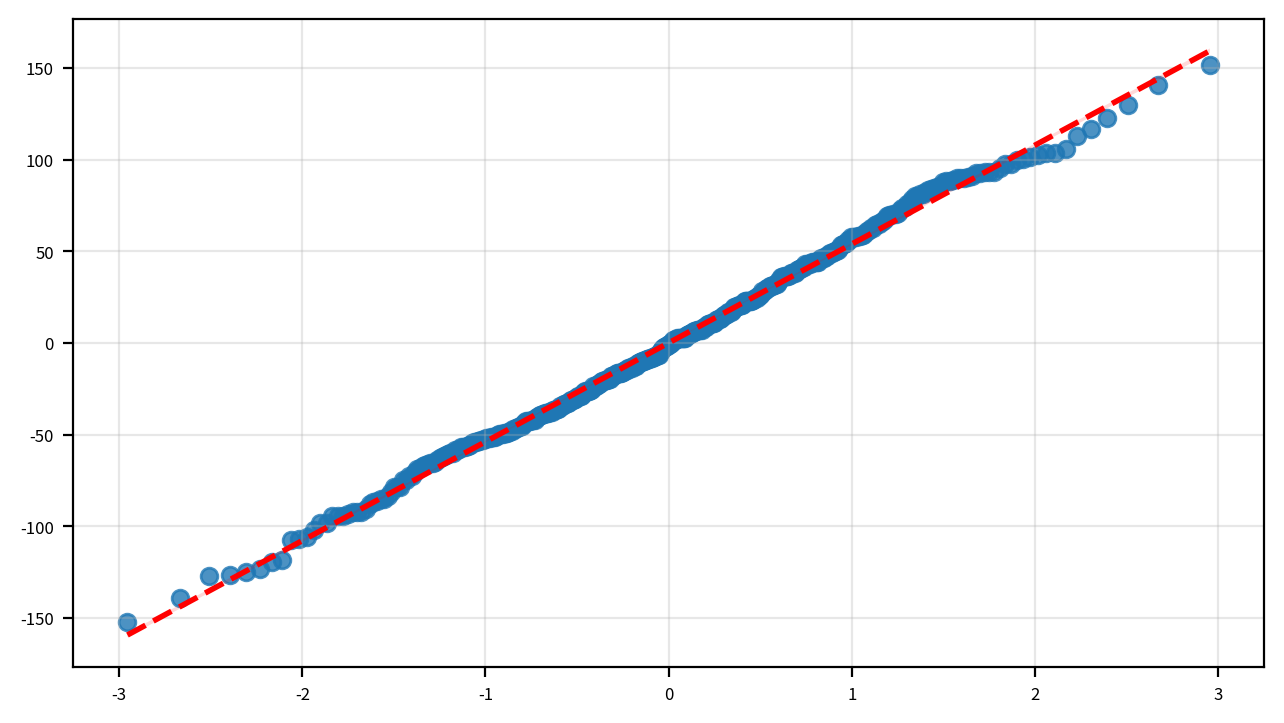

In [57]:
(x, y), _ = probplot(fit.resid)
# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) regplot 그리기
sb.regplot(x=x, y=y, line_kws={
"color": "red",
"linestyle": "--", # 점선
"linewidth": 2
})
# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3) # 배경 격자 표시
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

잔차도 시각화

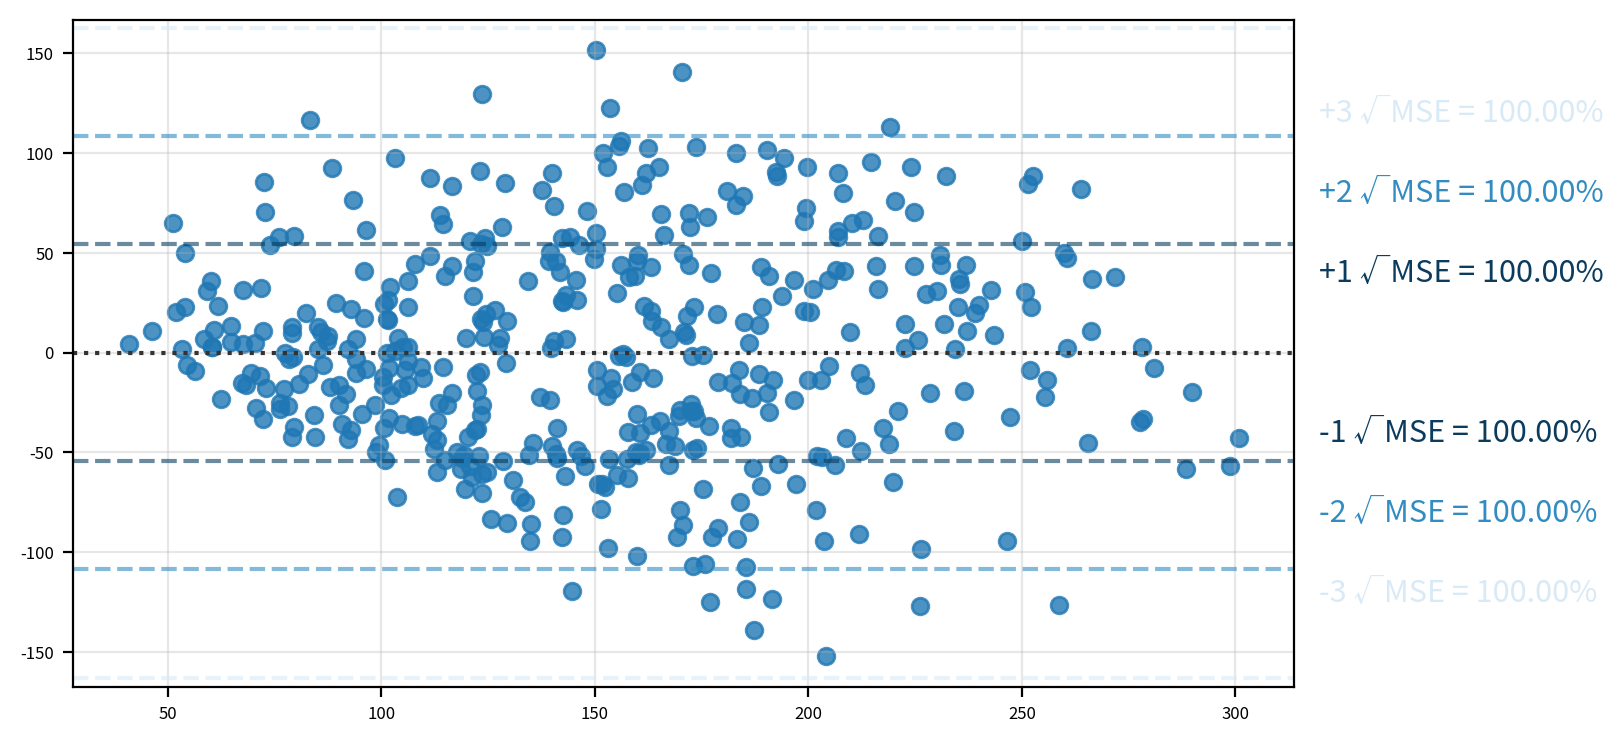

In [58]:
mse_sq = fit.mse_resid
mse_root = np.sqrt(mse_sq)

r = fit.resid  # 잔차

# 잔차가 ±1MSE, ±2MSE, ±3MSE 범위 안에 들어가는 비율(%)
r1 = r[(r > -mse_sq) & (r < mse_sq)].count() / r.count() * 100
r2 = r[(r > -2*mse_sq) & (r < 2*mse_sq)].count() / r.count() * 100
r3 = r[(r > -3*mse_sq) & (r < 3*mse_sq)].count() / r.count() * 100

mse_r = [r1, r2, r3]
colors = ["#0B3C5D", "#328CC1", "#D9EAF7"]

xmax = fit.fittedvalues.max()
ymin = fit.fittedvalues.min()

# 1) 그래프 초기화
width_px = 1600
height_px = 720
figsize = (width_px / my_dpi, height_px / my_dpi)

fig, ax = plt.subplots(
    1, 1,
    figsize=figsize,
    dpi=my_dpi,
    constrained_layout=True
)

# 2) seaborn 기본 잔차도
sb.residplot(x=fit.fittedvalues, y=fit.resid, ax=ax)

# 3) 꾸미기
ax.grid(True, alpha=0.3)

# 4) MSE 3단계 표시
for i, c in enumerate(colors):
    k = i + 1

    # 올바른 ±k√MSE 위치
    y_pos = k * mse_root

    ax.axhline(y=y_pos,  color=c, linestyle="--", alpha=0.6)
    ax.axhline(y=-y_pos, color=c, linestyle="--", alpha=0.6)

    # 텍스트는 축 좌표계 사용 (그래프 밖으로 안 나감)
    ax.text(
        x=1.02,
        y=0.5 + 0.12 * k,
        s=f"+{k} √MSE = {mse_r[i]:0.2f}%",
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=11,
        color=c
    )

    ax.text(
        x=1.02,
        y=0.5 - 0.12 * k,
        s=f"-{k} √MSE = {mse_r[i]:0.2f}%",
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=11,
        color=c
    )

# 5) 출력
plt.show()
plt.close()



📝 2. 잔차의 정규성 검정

In [59]:
if len(origin) < 5000:
    method = "Shapiro-Wilk"
    stat, p = shapiro(fit.resid)
    print(f"{method} statistic: {stat:.4f}, p-value: {p:.4f}")

    violated = p < 0.05

else:
    method = "Anderson-Darling"
    ad_res = anderson(fit.resid, dist='norm')

    crit_levels = ad_res.significance_level.tolist()
    crit_values = ad_res.critical_values.tolist()

    # 5% 임계값 찾기
    crit_5 = crit_values[crit_levels.index(5.0)] if 5.0 in crit_levels else None

    print(f"{method} statistic: {ad_res.statistic:.4f}, 5% 임계값: {crit_5:.4f}")

    violated = (crit_5 is not None) and (ad_res.statistic > crit_5)

# 결과 출력
print(
    "정규성 가정 위배 가능성이 있음 (5% 유의수준)"
    if violated
    else "정규성 가정 위배 근거 없음 (5% 유의수준)"
)


Shapiro-Wilk statistic: 0.9965, p-value: 0.4430
정규성 가정 위배 근거 없음 (5% 유의수준)


📝 3. 잔차의 등분산성<br>
표본 수가 30건보다 클 때 중심극한정리에 따라 잔차의 등분산성이 깨지더라도 분석 결과에 큰 영향을 주지않는다고 가정한다.

In [60]:
# Breusch–Pagan Test
names = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_test = het_breuschpagan(fit.resid, fit.model.exog)
bp = DataFrame(bp_test, index=names, columns=['value'])
# p-value는 F p-value를 기준으로 사용
p_bp = bp.loc['F p-value', 'value']
print(f"Breusch–Pagan statistic: {bp.loc['F Statistic','value']:.3f}, p-value ={p_bp:.3f}")
print(f"{'이분산성 존재(등분산 아님)' if p_bp <= 0.05 else '등분산성 만족'}")

Breusch–Pagan statistic: 2.932, p-value =0.002
이분산성 존재(등분산 아님)


📝 4. 잔차의 독립성

In [61]:
dw = durbin_watson(fit.resid)
if 1.5 <= dw <= 2.5:
    interpretation = "잔차는 독립성을 만족함 (자기상관 없음)"
elif dw < 1.5:
    interpretation = "잔차에 양(+)의 자기상관이 존재할 가능성 있음 (독립성 위반)"
else:
    interpretation = "잔차에 음(–)의 자기상관이 존재할 가능성 있음 (독립성 위반)"
print(f"Durbin–Watson: {dw:.3f}")
print(interpretation)

Durbin–Watson: 2.014
잔차는 독립성을 만족함 (자기상관 없음)
